# Introduction to Key Libraries for Regression Problems

In this notebook, we will explore the fundamental libraries used for regression problems in Python.
We will generate a dummy dataset, visualize the correlation between features, train a simple Linear Regression model, and evaluate its performance using standard metrics.

We will also introduce two important evaluation metrics:
- **Mean Squared Error (MSE)**: Measures the average squared difference between actual and predicted values. A lower MSE indicates a better fit.
- **R-squared (R²) Score**: Represents how well the independent variables explain the variance in the target variable. A value closer to 1 indicates a better fit.

  The formula for R² is:

$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

Where:
$$
y_i \text{ are the actual values}
$$
$$
\hat{y}_i \text{ are the predicted values}
$$
$$
\bar{y} \text{ is the mean of the actual values}
$$

In [14]:
import numpy as np  # Numerical computing
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns  # Advanced data visualization
from sklearn.model_selection import train_test_split  # Splitting dataset
from sklearn.preprocessing import StandardScaler  # Data scaling
from sklearn.linear_model import LinearRegression  # Linear Regression model
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics

,Feature1,Feature2,Feature3,Target
0,3.745401,0.314292,6.420316,11.327347
1,9.507143,6.364104,0.841400,27.218228
2,7.319939,3.143560,1.616287,26.247706
3,5.986585,5.085707,8.985542,19.227593
4,1.560186,9.075665,6.064291,0.630274


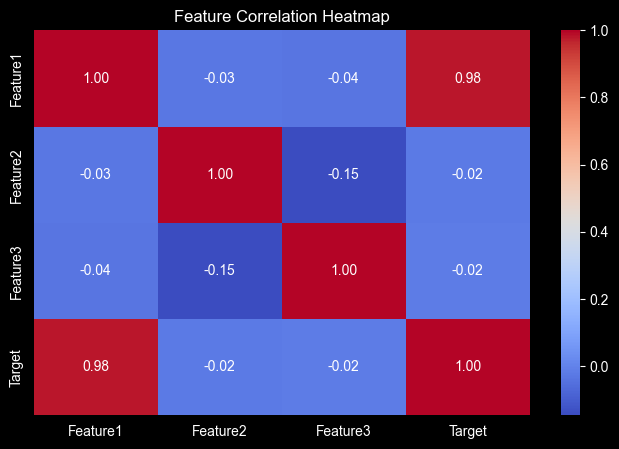

Mean Squared Error: 8.41
R-squared: 0.91


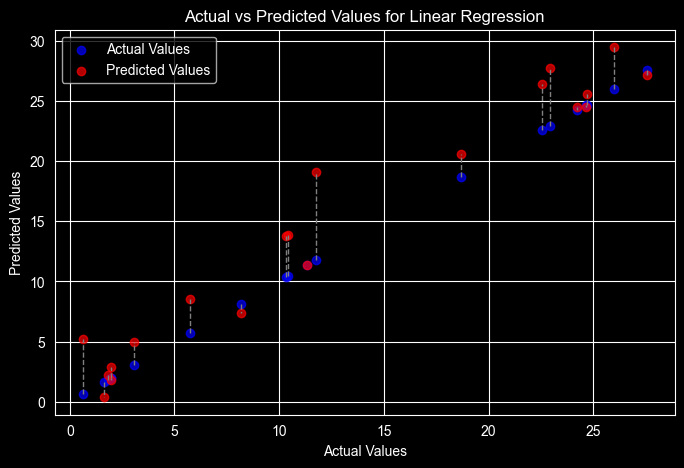

In [15]:
np.random.seed(42)
n_samples = 100

X1 = np.random.rand(n_samples) * 10 
X2 = np.random.rand(n_samples) * 10 
X3 = np.random.rand(n_samples) * 10 
Y = X1 * 3 + np.random.normal(0, 2, n_samples) 

df = pd.DataFrame({'Feature1': X1, 'Feature2': X2, 'Feature3': X3, 'Target': Y})

display(df.head())

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test, color='blue', label='Actual Values', alpha=0.7)
plt.scatter(y_test, y_pred, color='red', label='Predicted Values', alpha=0.7)

for actual, predicted in zip(y_test, y_pred):
    plt.plot([actual, actual], [actual, predicted], color='gray', linestyle='dashed', linewidth=1)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values for Linear Regression")
plt.legend()
plt.show()

### Lab Work - Predict how many medals will an athelete win

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/cstorm125/information_value/refs/heads/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv"
df = pd.read_csv(url)
print("Dataset Overview:")
print(df.info())
print(df.head(5))


Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 56.6 MB
None
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2            

In [13]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID                0
Name              0
Sex               0
Age            9474
Height        60171
Weight        62875
Team              0
NOC               0
Games             0
Year              0
Season            0
City              0
Sport             0
Event             0
Medal        231333
won_medal         0
dtype: int64


In [14]:
df["won_medal"] = df["Medal"].notnull().astype(int)

ath = (
    df.groupby(["ID", "Name"], as_index=False)
      .agg(
          medals_actual=("won_medal", "sum"), # target
          entries=("Year", "count"),
          games_count=("Games", "nunique"),
          sports_count=("Sport", "nunique"),
          events_count=("Event", "nunique"),
          mean_age=("Age", "mean"),
          mean_height=("Height", "mean"),
          mean_weight=("Weight", "mean"),
          sex=("Sex", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan),
          noc=("NOC", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
      )
)

# we try to keep only the atheletes who won at least one medal, since predicting 0 medals is trivial and not interesting
ath = ath[ath["medals_actual"] > 0].copy()

print(ath.head(5))
num_cols = ath.select_dtypes(include=[np.number]).columns
ath[num_cols] = ath[num_cols].fillna(ath[num_cols].median())
print(ath.head(5))


    ID                      Name  medals_actual  entries  games_count  \
3    4      Edgar Lindenau Aabye              1        1            1   
14  15      Arvo Ossian Aaltonen              2        5            3   
15  16  Juhamatti Tapio Aaltonen              1        1            1   
16  17   Paavo Johannes Aaltonen              5       16            2   
19  20        Kjetil Andr Aamodt              8       20            5   

    sports_count  events_count  mean_age  mean_height  mean_weight sex  noc  
3              1             1      34.0          NaN          NaN   M  DEN  
14             1             2      27.6          NaN          NaN   M  FIN  
15             1             1      28.0        184.0         85.0   M  FIN  
16             1             8      30.0        175.0         64.0   M  FIN  
19             1             5      25.6        176.0         85.0   M  NOR  
    ID                      Name  medals_actual  entries  games_count  \
3    4      Edgar Li

Mean Squared Error: 0.62
R-squared: 0.38


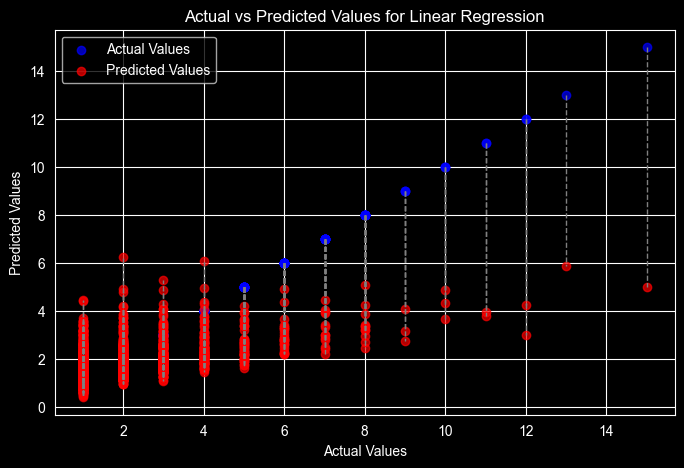

In [15]:
y = ath["medals_actual"] # target

# we drop identifiers and the target variable
X = ath.drop(columns=["ID", "Name", "medals_actual"]).copy()

# added efficiency feature
min_count = 30
noc_count = X["noc"].value_counts()
rare_nocs = noc_count[noc_count < min_count].index
X["noc"] = X["noc"].mask(X["noc"].isin(rare_nocs), "OTHER")

# one-hot encode categorical variables
X = pd.get_dummies(X, columns=["sex", "noc"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# medals cannot be negative, so we clip predictions to be at least 0
y_pred = np.clip(y_pred, 0, None)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test, color='blue', label='Actual Values', alpha=0.7)
plt.scatter(y_test, y_pred, color='red', label='Predicted Values', alpha=0.7)

for actual, predicted in zip(y_test, y_pred):
    plt.plot([actual, actual], [actual, predicted], color='gray', linestyle='dashed', linewidth=1)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values for Linear Regression")
plt.legend()
plt.show()
